In [1]:
import pandas as pd
print(pd.__version__)

3.0.2


In [2]:
obj = pd.Series([4, 7, -5, 3])
print(obj)
obj.values
obj.index

0    4
1    7
2   -5
3    3
dtype: int64


RangeIndex(start=0, stop=4, step=1)

In [3]:
import numpy as np


obj2 = pd.Series([4, 7, -5, 3], index=['d', 'b', 'a', 'c'])
obj2.sort_index()
obj2.values
obj2.index
print(obj2)
obj2['a']
print(int(obj2['a']))
obj2[['c', 'a', 'd']] # ['c', 'a', 'd']是索引列表，即使它包含的是字符串而不是整数。
obj2[obj2 > 0]
obj2 * 2 # type: ignore
np.exp(obj2)  # noqa: F821

'b' in obj2

d    4
b    7
a   -5
c    3
dtype: int64
-5


True

In [4]:
sdata = {'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}
obj3 = pd.Series(sdata)
print(obj3)
obj3['Ohio']

states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, index=states)
print(f'\n{obj4}')

pd.isnull(obj4) # 判断是否为空
pd.notnull(obj4)
obj4.isnull()

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64


California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [5]:
sdata = {'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}
obj3 = pd.Series(sdata)

states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, index=states)

obj3 + obj4

California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64

In [6]:
sdata = {'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}
states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, index=states)

obj4.name = 'population'
obj4.index.name = 'state'

obj4.index = ['Bob', 'Steve', 'Jeff', 'Ryan'] # 重新设置索引,索引名会重置
obj4.index.name = 'name'
print(obj4)

obj4.index = pd.Index(['California', 'Ohio', 'Oregon', 'Texas'], name='states')
print(obj4)

name
Bob          NaN
Steve    35000.0
Jeff     16000.0
Ryan     71000.0
Name: population, dtype: float64
states
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: population, dtype: float64


In [7]:
data = {'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
        'year': [2000, 2001, 2002, 2001, 2002, 2003],
        'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}
frame = pd.DataFrame(data)
print(frame)

frame.head()

    state  year  pop
0    Ohio  2000  1.5
1    Ohio  2001  1.7
2    Ohio  2002  3.6
3  Nevada  2001  2.4
4  Nevada  2002  2.9
5  Nevada  2003  3.2


,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9


In [8]:
pd.DataFrame(data, columns=['year', 'state', 'pop'])

,year,state,pop
0,2000,Ohio,1.5
1,2001,Ohio,1.7
2,2002,Ohio,3.6
3,2001,Nevada,2.4
4,2002,Nevada,2.9
5,2003,Nevada,3.2


In [9]:
frame2 = pd.DataFrame(data, columns=['year', 'state', 'pop', 'debt'],
index=['one', 'two', 'three', 'four', 'five', 'six'])
print(frame2)

frame2.columns


       year   state  pop debt
one    2000    Ohio  1.5  NaN
two    2001    Ohio  1.7  NaN
three  2002    Ohio  3.6  NaN
four   2001  Nevada  2.4  NaN
five   2002  Nevada  2.9  NaN
six    2003  Nevada  3.2  NaN


Index(['year', 'state', 'pop', 'debt'], dtype='str')

In [10]:
frame2['state']

one        Ohio
two        Ohio
three      Ohio
four     Nevada
five     Nevada
six      Nevada
Name: state, dtype: str

In [11]:
frame2.year

one      2000
two      2001
three    2002
four     2001
five     2002
six      2003
Name: year, dtype: int64

In [12]:
frame2.loc['three']

year     2002
state    Ohio
pop       3.6
debt      NaN
Name: three, dtype: object

In [13]:
frame2['debt'] = [1,2,3,4,5,6]
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,1
two,2001,Ohio,1.7,2
three,2002,Ohio,3.6,3
four,2001,Nevada,2.4,4
five,2002,Nevada,2.9,5
six,2003,Nevada,3.2,6


In [14]:
frame2['debt'] = np.arange(6.)
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,0.0
two,2001,Ohio,1.7,1.0
three,2002,Ohio,3.6,2.0
four,2001,Nevada,2.4,3.0
five,2002,Nevada,2.9,4.0
six,2003,Nevada,3.2,5.0


In [15]:
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
frame2['debt'] = val
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


In [16]:
frame2['eastern'] = frame2.state == 'Ohio'
del frame2['eastern']

frame2.columns

Index(['year', 'state', 'pop', 'debt'], dtype='str')

In [17]:
pop = {'Nevada': {2001: 2.4, 2002: 2.9},
'Ohio': {2000: 1.5, 2001: 1.7, 2002: 3.6}}
frame3 = pd.DataFrame(pop)
frame3

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


In [18]:
frame3.T

,2001,2002,2000
Nevada,2.4,2.9,NaN
Ohio,1.7,3.6,1.5


In [19]:
pd.DataFrame(pop, index=[2001, 2002, 2003])
# 内层字典的键会被合并、排序以形成最终的索引。如果明确指定了索引，则不会这样


,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2003,NaN,NaN


In [20]:
obj = pd.Series([4, 7, -5, 3], index=['d', 'b', 'a', 'c'])
obj2 = obj.reindex(['a', 'b', 'c', 'd', 'e'])
obj2

a   -5.0
b    7.0
c    3.0
d    4.0
e    NaN
dtype: float64

In [21]:
obj3 = pd.Series(['blue', 'purple', 'yellow'], index=[0, 2, 4])
obj3.reindex(range(6), method='ffill')

0      blue
1      blue
2    purple
3    purple
4    yellow
5    yellow
dtype: str

In [22]:
frame = pd.DataFrame(np.arange(10).reshape(5, 2), index = ['a','b','c','d','e'],columns=['A', 'B'])
frame

,A,B
a,0,1
b,2,3
c,4,5
d,6,7
e,8,9


In [23]:
frame2 = frame.reindex(['a', 'b', 'c', 'd','e','f'])
frame2

,A,B
a,0.0,1.0
b,2.0,3.0
c,4.0,5.0
d,6.0,7.0
e,8.0,9.0
f,NaN,NaN


In [24]:
states = ['A', 'B', 'C']
frame2.reindex(columns=states)

,A,B,C
a,0.0,1.0,NaN
b,2.0,3.0,NaN
c,4.0,5.0,NaN
d,6.0,7.0,NaN
e,8.0,9.0,NaN
f,NaN,NaN,NaN


In [25]:
obj = pd.Series(np.arange(5.), index=['a', 'b', 'c', 'd', 'e'])
new_obj = obj.drop('c')
new_obj = obj.drop(['d', 'c'])
new_obj


a    0.0
b    1.0
e    4.0
dtype: float64

In [26]:
frame = pd.DataFrame(np.arange(16).reshape(4, 4), index=['Ohio', 'Colorado', 'Utah', 'New York'],columns=['A', 'B', 'C', 'D'])
new_frame = frame.drop('Ohio')
new_frame

,A,B,C,D
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [27]:
new_frame2 = frame.drop(['A','B'],axis = 'columns')
new_frame2

,C,D
Ohio,2,3
Colorado,6,7
Utah,10,11
New York,14,15


In [28]:
obj.drop('c', inplace=True) # inplace=True是改变原对象,小心使用inplace，它会销毁所有被删除的数据
obj 

a    0.0
b    1.0
d    3.0
e    4.0
dtype: float64

In [29]:
obj = pd.Series(np.arange(4.), index=['a', 'b', 'c', 'd'])

print(obj['b'])          # 按标签
print(obj.iloc[1])       # 按位置
print(obj.iloc[2:4])     # 按位置切片
print(obj[['b', 'a', 'd']])  # 按标签列表
print(obj.iloc[[1, 3]])  # 按位置列表
print(obj[obj < 2])      # 布尔筛选
print(obj['b':'c'])      # 按标签切片，包含 c

obj['b':'c'] = 5
print(obj)

1.0
1.0
c    2.0
d    3.0
dtype: float64
b    1.0
a    0.0
d    3.0
dtype: float64
b    1.0
d    3.0
dtype: float64
a    0.0
b    1.0
dtype: float64
b    1.0
c    2.0
dtype: float64
a    0.0
b    5.0
c    5.0
d    3.0
dtype: float64


In [30]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    np.arange(12).reshape(3, 4),
    index=['a', 'b', 'c'],
    columns=['one', 'two', 'three', 'four']
)

print(df)

print(df['one'])
print(df[['one', 'three']])

print(df.loc['b']) 
# df.loc 是 pandas 里按标签索引的工具，也就是说，它不是按“第几行、第几列”取数据，而是按 行名 index 和 列名 columns 取数据
print(df.iloc[1])
print(df.loc[['a', 'c']])

print(df.loc['b', 'three'])
print(df.loc[['a', 'c'], ['one', 'four']])

print(df.iloc[1, 2])
print(df.iloc[[0, 2], [0, 3]])

print(df.loc['a':'b', 'two':'four'])
print(df.iloc[0:2, 1:4])

# df['列名']              # 取列
# df.loc['行标签']        # 按行标签取行
# df.iloc[行位置]          # 按行位置取行

# df.loc[行标签, 列标签]    # 按标签取某个值
# df.iloc[行位置, 列位置]  # 按位置取某个值

   one  two  three  four
a    0    1      2     3
b    4    5      6     7
c    8    9     10    11
a    0
b    4
c    8
Name: one, dtype: int64
   one  three
a    0      2
b    4      6
c    8     10
one      4
two      5
three    6
four     7
Name: b, dtype: int64
one      4
two      5
three    6
four     7
Name: b, dtype: int64
   one  two  three  four
a    0    1      2     3
c    8    9     10    11
6
   one  four
a    0     3
c    8    11
6
   one  four
a    0     3
c    8    11
   two  three  four
a    1      2     3
b    5      6     7
   two  three  four
a    1      2     3
b    5      6     7


In [31]:
dates = pd.date_range("20130101", periods=6)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))
df

,A,B,C,D
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-03,-0.494870,0.997674,2.518915,0.866387
2013-01-04,-2.252592,-1.217110,0.819122,1.093233
2013-01-05,0.086709,0.278652,-1.041399,1.037166
2013-01-06,0.843684,1.542972,-0.317450,0.122947


In [32]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


In [33]:
df.head(2)

,A,B,C,D
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747
2013-01-02,0.615301,-0.413684,-0.419311,0.512124


In [34]:
df.tail(2)

,A,B,C,D
2013-01-05,0.086709,0.278652,-1.041399,1.037166
2013-01-06,0.843684,1.542972,-0.317450,0.122947


In [35]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[us]', freq='D')

In [36]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='str')

In [37]:
df.to_numpy()

array([[-0.90937631,  0.42435435, -0.31046594, -1.00874744],
       [ 0.61530145, -0.41368365, -0.41931131,  0.51212446],
       [-0.49487004,  0.99767387,  2.51891495,  0.86638691],
       [-2.25259206, -1.21710974,  0.81912174,  1.09323291],
       [ 0.08670886,  0.27865176, -1.04139859,  1.0371661 ],
       [ 0.84368432,  1.54297238, -0.31745005,  0.12294679]])

In [38]:
df2.dtypes

A           float64
B    datetime64[us]
C           float32
D             int32
E          category
F               str
dtype: object

In [39]:
df2.to_numpy()

array([[1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo']],
      dtype=object)

In [40]:
df.describe() # 描述统计

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.351857,0.268810,0.208235,0.437185
std,1.140274,0.985168,1.281657,0.796200
min,-2.252592,-1.217110,-1.041399,-1.008747
25%,-0.805750,-0.240600,-0.393846,0.220241
50%,-0.204081,0.351503,-0.313958,0.689256
75%,0.483153,0.854344,0.536725,0.994471
max,0.843684,1.542972,2.518915,1.093233


In [41]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,-0.909376,0.615301,-0.494870,-2.252592,0.086709,0.843684
B,0.424354,-0.413684,0.997674,-1.217110,0.278652,1.542972
C,-0.310466,-0.419311,2.518915,0.819122,-1.041399,-0.317450
D,-1.008747,0.512124,0.866387,1.093233,1.037166,0.122947


In [42]:
df.sort_index(axis=1, ascending=False) # ascending=False means descending

,D,C,B,A
2013-01-01,-1.008747,-0.310466,0.424354,-0.909376
2013-01-02,0.512124,-0.419311,-0.413684,0.615301
2013-01-03,0.866387,2.518915,0.997674,-0.494870
2013-01-04,1.093233,0.819122,-1.217110,-2.252592
2013-01-05,1.037166,-1.041399,0.278652,0.086709
2013-01-06,0.122947,-0.317450,1.542972,0.843684


In [43]:
df.sort_values(by="B")

,A,B,C,D
2013-01-04,-2.252592,-1.217110,0.819122,1.093233
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-05,0.086709,0.278652,-1.041399,1.037166
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747
2013-01-03,-0.494870,0.997674,2.518915,0.866387
2013-01-06,0.843684,1.542972,-0.317450,0.122947


In [44]:
df["A"]

2013-01-01   -0.909376
2013-01-02    0.615301
2013-01-03   -0.494870
2013-01-04   -2.252592
2013-01-05    0.086709
2013-01-06    0.843684
Freq: D, Name: A, dtype: float64

In [45]:
df.A

2013-01-01   -0.909376
2013-01-02    0.615301
2013-01-03   -0.494870
2013-01-04   -2.252592
2013-01-05    0.086709
2013-01-06    0.843684
Freq: D, Name: A, dtype: float64

In [46]:
df[["B", "A"]]

,B,A
2013-01-01,0.424354,-0.909376
2013-01-02,-0.413684,0.615301
2013-01-03,0.997674,-0.494870
2013-01-04,-1.217110,-2.252592
2013-01-05,0.278652,0.086709
2013-01-06,1.542972,0.843684


In [47]:
df[0:3]

,A,B,C,D
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-03,-0.494870,0.997674,2.518915,0.866387


In [48]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-03,-0.494870,0.997674,2.518915,0.866387
2013-01-04,-2.252592,-1.217110,0.819122,1.093233


In [49]:
df

,A,B,C,D
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-03,-0.494870,0.997674,2.518915,0.866387
2013-01-04,-2.252592,-1.217110,0.819122,1.093233
2013-01-05,0.086709,0.278652,-1.041399,1.037166
2013-01-06,0.843684,1.542972,-0.317450,0.122947


In [50]:
df.loc[dates[0]]

A   -0.909376
B    0.424354
C   -0.310466
D   -1.008747
Name: 2013-01-01 00:00:00, dtype: float64

In [51]:
df.loc[:,['A','B']] # : all rows

,A,B
2013-01-01,-0.909376,0.424354
2013-01-02,0.615301,-0.413684
2013-01-03,-0.494870,0.997674
2013-01-04,-2.252592,-1.217110
2013-01-05,0.086709,0.278652
2013-01-06,0.843684,1.542972


In [52]:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,0.615301,-0.413684
2013-01-03,-0.494870,0.997674
2013-01-04,-2.252592,-1.217110


In [53]:
df.loc[dates[0], "A"]

np.float64(-0.9093763060889832)

In [54]:
df.at[dates[0], "A"]

np.float64(-0.9093763060889832)

In [55]:
df.iloc[3]

A   -2.252592
B   -1.217110
C    0.819122
D    1.093233
Name: 2013-01-04 00:00:00, dtype: float64

In [56]:
df.iloc[3:5, 0:2]

,A,B
2013-01-04,-2.252592,-1.217110
2013-01-05,0.086709,0.278652


In [57]:
df.iloc[[1, 2, 4], [0, 2]]

,A,C
2013-01-02,0.615301,-0.419311
2013-01-03,-0.494870,2.518915
2013-01-05,0.086709,-1.041399


In [58]:
df.iloc[1:3, :]

,A,B,C,D
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-03,-0.494870,0.997674,2.518915,0.866387


In [59]:
df.iloc[:, 1:3]

,B,C
2013-01-01,0.424354,-0.310466
2013-01-02,-0.413684,-0.419311
2013-01-03,0.997674,2.518915
2013-01-04,-1.217110,0.819122
2013-01-05,0.278652,-1.041399
2013-01-06,1.542972,-0.317450


In [60]:
df.iloc[1, 1]

np.float64(-0.4136836536901908)

In [61]:
df.iat[1, 1] # iat用于快速访问单个元素

np.float64(-0.4136836536901908)

In [62]:
df[df["A"] > 0]

,A,B,C,D
2013-01-02,0.615301,-0.413684,-0.419311,0.512124
2013-01-05,0.086709,0.278652,-1.041399,1.037166
2013-01-06,0.843684,1.542972,-0.317450,0.122947


In [63]:
df[df > 0]

,A,B,C,D
2013-01-01,NaN,0.424354,NaN,NaN
2013-01-02,0.615301,NaN,NaN,0.512124
2013-01-03,NaN,0.997674,2.518915,0.866387
2013-01-04,NaN,NaN,0.819122,1.093233
2013-01-05,0.086709,0.278652,NaN,1.037166
2013-01-06,0.843684,1.542972,NaN,0.122947


In [64]:
df2 = df.copy()
df2["E"] = ["one", "one", "two", "three", "four", "three"]
df2

,A,B,C,D,E
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747,one
2013-01-02,0.615301,-0.413684,-0.419311,0.512124,one
2013-01-03,-0.494870,0.997674,2.518915,0.866387,two
2013-01-04,-2.252592,-1.217110,0.819122,1.093233,three
2013-01-05,0.086709,0.278652,-1.041399,1.037166,four
2013-01-06,0.843684,1.542972,-0.317450,0.122947,three


In [65]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,E
2013-01-03,-0.494870,0.997674,2.518915,0.866387,two
2013-01-05,0.086709,0.278652,-1.041399,1.037166,four


In [66]:
s1 = pd.Series(
   [1, 2, 3, 4, 5, 6],
   index=pd.date_range("20130102", periods=6))
s1
# "Freq: D" 在 pandas 中表示时间序列的频率是日频率（Daily）

2013-01-02    1
2013-01-03    2
2013-01-04    3
2013-01-05    4
2013-01-06    5
2013-01-07    6
Freq: D, dtype: int64

In [67]:
df["F"] = s1
df

,A,B,C,D,F
2013-01-01,-0.909376,0.424354,-0.310466,-1.008747,NaN
2013-01-02,0.615301,-0.413684,-0.419311,0.512124,1.0
2013-01-03,-0.494870,0.997674,2.518915,0.866387,2.0
2013-01-04,-2.252592,-1.217110,0.819122,1.093233,3.0
2013-01-05,0.086709,0.278652,-1.041399,1.037166,4.0
2013-01-06,0.843684,1.542972,-0.317450,0.122947,5.0


In [68]:
df.at[dates[0], "A"] = 0
df

,A,B,C,D,F
2013-01-01,0.000000,0.424354,-0.310466,-1.008747,NaN
2013-01-02,0.615301,-0.413684,-0.419311,0.512124,1.0
2013-01-03,-0.494870,0.997674,2.518915,0.866387,2.0
2013-01-04,-2.252592,-1.217110,0.819122,1.093233,3.0
2013-01-05,0.086709,0.278652,-1.041399,1.037166,4.0
2013-01-06,0.843684,1.542972,-0.317450,0.122947,5.0


In [69]:
df.iat[0, 1] = 0
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.310466,-1.008747,NaN
2013-01-02,0.615301,-0.413684,-0.419311,0.512124,1.0
2013-01-03,-0.494870,0.997674,2.518915,0.866387,2.0
2013-01-04,-2.252592,-1.217110,0.819122,1.093233,3.0
2013-01-05,0.086709,0.278652,-1.041399,1.037166,4.0
2013-01-06,0.843684,1.542972,-0.317450,0.122947,5.0


In [70]:
len(df)

6

In [71]:
df.loc[:, "D"] = np.array([5] * len(df))
df


,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.310466,5.0,NaN
2013-01-02,0.615301,-0.413684,-0.419311,5.0,1.0
2013-01-03,-0.494870,0.997674,2.518915,5.0,2.0
2013-01-04,-2.252592,-1.217110,0.819122,5.0,3.0
2013-01-05,0.086709,0.278652,-1.041399,5.0,4.0
2013-01-06,0.843684,1.542972,-0.317450,5.0,5.0


In [72]:
df2 = df.copy()
df2[df2 > 0] = -df2[df2 > 0]
df2


,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.310466,-5.0,NaN
2013-01-02,-0.615301,-0.413684,-0.419311,-5.0,-1.0
2013-01-03,-0.494870,-0.997674,-2.518915,-5.0,-2.0
2013-01-04,-2.252592,-1.217110,-0.819122,-5.0,-3.0
2013-01-05,-0.086709,-0.278652,-1.041399,-5.0,-4.0
2013-01-06,-0.843684,-1.542972,-0.317450,-5.0,-5.0


In [73]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])
df1.loc[dates[0]:dates[1], "E"] = 1
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-0.310466,5.0,NaN,1.0
2013-01-02,0.615301,-0.413684,-0.419311,5.0,1.0,1.0
2013-01-03,-0.494870,0.997674,2.518915,5.0,2.0,NaN
2013-01-04,-2.252592,-1.217110,0.819122,5.0,3.0,NaN


In [74]:
df1.dropna(how="any")

,A,B,C,D,F,E
2013-01-02,0.615301,-0.413684,-0.419311,5.0,1.0,1.0


In [75]:
df1.fillna(value=5) # inplace=True意思是在原数据上操作，不返回新的数据



,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-0.310466,5.0,5.0,1.0
2013-01-02,0.615301,-0.413684,-0.419311,5.0,1.0,1.0
2013-01-03,-0.494870,0.997674,2.518915,5.0,2.0,5.0
2013-01-04,-2.252592,-1.217110,0.819122,5.0,3.0,5.0


In [76]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


In [77]:
import sklearn
sklearn.__version__

'1.8.0'

In [78]:
# 导入必要的库
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. 加载数据
iris = load_iris()
X = iris.data  # 特征数据
y = iris.target  # 标签数据

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 创建模型（随机森林分类器）
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. 训练模型
model.fit(X_train, y_train)

# 5. 预测
y_pred = model.predict(X_test)

# 6. 评估模型
accuracy = accuracy_score(y_test, y_pred)
print(f"准确率: {accuracy:.2f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


准确率: 1.00

分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [79]:
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-0.310466,5.0,NaN
2013-01-02,0.615301,-0.413684,-0.419311,5.0,1.0
2013-01-03,-0.494870,0.997674,2.518915,5.0,2.0
2013-01-04,-2.252592,-1.217110,0.819122,5.0,3.0
2013-01-05,0.086709,0.278652,-1.041399,5.0,4.0
2013-01-06,0.843684,1.542972,-0.317450,5.0,5.0


In [80]:
df.mean()

A   -0.200295
B    0.198084
C    0.208235
D    5.000000
F    3.000000
dtype: float64

In [81]:
df.mean(axis=1)

2013-01-01    1.172384
2013-01-02    1.156461
2013-01-03    2.004344
2013-01-04    1.069884
2013-01-05    1.664792
2013-01-06    2.413841
Freq: D, dtype: float64

In [82]:
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[us]', freq='D')

In [83]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
df.sub(s, axis="index")
# shift(2)	向后移动2位（数据向下移动）
# df.sub() 是 pandas 中的减法操作方法，用于对 DataFrame 或 Series 进行减法运算

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-1.494870,-0.002326,1.518915,4.0,1.0
2013-01-04,-5.252592,-4.217110,-2.180878,2.0,0.0
2013-01-05,-4.913291,-4.721348,-6.041399,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


In [84]:
import pandas as pd
import numpy as np

# 创建 DataFrame
df = pd.DataFrame({
    'A': [10, 20, 30],
    'B': [100, 200, 300]
})

# 创建 Series
s = pd.Series([1, 2, 3])

# 执行减法
result = df.sub(s, axis=0)  # 按行索引对齐
print(result)

    A    B
0   9   99
1  18  198
2  27  297


In [85]:
df = pd.DataFrame(np.random.randn(6, 6), columns=['A', 'B', 'C', 'D', 'E', 'F'], index=dates)
df.agg(lambda x: np.mean(x) * 5.6)
# df.agg() 是 pandas 中的聚合方法，用于对数据进行汇总计算，结合 lambda 函数可以实现自定义聚合
# 当 agg() 执行时，它会按列（或按行）迭代，每次把一列数据传递给 lambda 函数


A    2.188854
B    1.784916
C    2.723201
D   -0.541290
E   -1.059364
F    0.229613
dtype: float64

In [86]:
x = pd.Series([1, 2, 3, 4, 5])
float(np.mean(x))

# NumPy 函数会自动处理 pandas Series，因为 pandas Series 是基于 NumPy 数组的
# NumPy 函数能识别类数组对象，如 pandas Series、DataFrame 等


3.0

In [87]:
import pandas as pd
import numpy as np

s = pd.Series([1, 2, 3, 4, 5])

# 三种写法结果相同：
print(np.mean(s))      # 3.0
print(s.mean())        # 3.0
print(s.values.mean()) # 3.0

3.0
3.0
3.0


In [88]:
df.transform(lambda x: x * 101.2)
# df.transform() 是 pandas 中的转换方法，用于对数据进行转换，结合 lambda 函数可以实现自定义转换

,A,B,C,D,E,F
2013-01-01,215.310832,-12.613931,-20.823813,103.927881,-21.954432,-5.075951
2013-01-02,-75.316497,42.375713,-86.168904,61.897294,-51.522908,-12.668288
2013-01-03,-28.157085,147.229732,75.558262,-118.978501,-151.404563,6.453488
2013-01-04,18.273916,73.631304,-51.627344,-63.374249,165.295607,-45.354096
2013-01-05,-122.416326,-91.172027,173.525757,-99.741687,-125.075757,-29.241249
2013-01-06,229.639467,34.085074,204.808867,57.577934,69.796757,110.782678


In [89]:
# 1. 标准化（保留原数据形状）
df.transform(lambda x: (x - x.mean()) / x.std())

# 2. 每个元素乘以该列的平均值
df.transform(lambda x: x * x.mean())

# 3. 对每列应用不同的转换
df.transform({
    'A': lambda x: x * 2,
    'B': lambda x: x / 10
})


,A,B
2013-01-01,4.255155,-0.012464
2013-01-02,-1.488468,0.041873
2013-01-03,-0.556464,0.145484
2013-01-04,0.361145,0.072758
2013-01-05,-2.419295,-0.090091
2013-01-06,4.538329,0.033681


In [90]:
s = pd.Series(np.random.randint(0, 7, size=10)) # 生成 10 个随机整数，范围 [0, 6]
s.value_counts().sort_index() # 统计每个值出现的次数

2    1
3    2
5    3
6    4
Name: count, dtype: int64

In [91]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])

s.str.lower() # 将每个字符串转换为小写

0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: str

In [92]:
df = pd.DataFrame(np.random.randn(10, 4))
pieces = [df[:3], df[3:7], df[7:]]
pd.concat(pieces) # 按行拼接

# 在 pandas 中，df[start:end] 默认按行索引切片，不需要指定 axis

,0,1,2,3
0,-0.238917,-0.969474,-0.205656,-0.664298
1,0.490278,0.170161,-0.964206,1.305128
2,-0.145830,-0.308176,-1.044203,0.815805
3,-0.910508,-0.839719,-0.518171,-0.205724
4,-2.274955,1.269310,-0.540836,0.459383
5,-1.290624,1.048728,-2.321814,0.512629
6,1.610389,-0.733683,1.146542,-0.529845
7,-1.273588,0.146569,0.342950,-0.638132
8,-1.274298,-1.034441,1.756230,0.695837
9,-0.562316,1.448777,0.644254,0.605180


In [93]:
df.loc[1]
df.loc[1:7,[1,3]]
df.loc[[1,3,5],[1,3]]

,1,3
1,0.170161,1.305128
3,-0.839719,-0.205724
5,1.048728,0.512629


In [94]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
pd.merge(left, right, on="key") # 按 key 合并


,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


In [95]:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,bar,2,5


In [96]:
import pandas as pd

# 成绩表1
df1 = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie'],
    'score': [85, 92, 78]
})

# 成绩表2
df2 = pd.DataFrame({
    'name': ['David', 'Eve'],
    'score': [88, 95]
})

# concat：把两个表垂直拼接
result = pd.concat([df1, df2])
result


,name,score
0,Alice,85
1,Bob,92
2,Charlie,78
0,David,88
1,Eve,95


In [97]:
# 学生表
students = pd.DataFrame({
    'student_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David']
})

# 成绩表
scores = pd.DataFrame({
    'student_id': [1, 2, 3, 5],
    'score': [85, 92, 78, 90]
})

# merge：按 student_id 合并
result = pd.merge(students, scores, on='student_id') # 内连接，只保留同时在两个表中都有 student_id 的行
result


,student_id,name,score
0,1,Alice,85
1,2,Bob,92
2,3,Charlie,78


In [98]:
# # inner join（默认）：只保留两边都有的
# pd.merge(left, right, on='key', how='inner')

# # left join：保留左边全部
# pd.merge(left, right, on='key', how='left')

# # right join：保留右边全部
# pd.merge(left, right, on='key', how='right')

# # outer join：保留两边全部
# pd.merge(left, right, on='key', how='outer')
# # inner join（默认）：只保留两边都有的
# pd.merge(left, right, on='key', how='inner')

# # left join：保留左边全部
# pd.merge(left, right, on='key', how='left')

# # right join：保留右边全部
# pd.merge(left, right, on='key', how='right')

# # outer join：保留两边全部
# pd.merge(left, right, on='key', how='outer')

students = pd.DataFrame({
    'student_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David']
})

scores = pd.DataFrame({
    'student_id': [1, 2, 3],
    'score': [85, 92, 78]
})

result = pd.merge(students, scores, on='student_id', how='left')
result



,student_id,name,score
0,1,Alice,85.0
1,2,Bob,92.0
2,3,Charlie,78.0
3,4,David,NaN


In [99]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
df

,A,B,C,D
0,foo,one,-0.482200,-1.046071
1,bar,one,-0.579744,0.861388
2,foo,two,-0.325484,0.715142
3,bar,three,-1.456892,-0.065558
4,foo,two,-0.774223,0.503151
5,bar,two,1.154856,-1.705872
6,foo,one,1.982705,0.262640
7,foo,three,0.131561,-0.460502


In [100]:
grouped = df.groupby("A")[["C", "D"]]
print(grouped.groups) # 查看每组包含的索引
print(grouped.get_group('foo'))

for name, group in df.groupby("A"):
    print(f"=== 组名: {name} ===")
    print(f'{group}\n')



{'bar': [1, 3, 5], 'foo': [0, 2, 4, 6, 7]}
          C         D
0 -0.482200 -1.046071
2 -0.325484  0.715142
4 -0.774223  0.503151
6  1.982705  0.262640
7  0.131561 -0.460502
=== 组名: bar ===
     A      B         C         D
1  bar    one -0.579744  0.861388
3  bar  three -1.456892 -0.065558
5  bar    two  1.154856 -1.705872

=== 组名: foo ===
     A      B         C         D
0  foo    one -0.482200 -1.046071
2  foo    two -0.325484  0.715142
4  foo    two -0.774223  0.503151
6  foo    one  1.982705  0.262640
7  foo  three  0.131561 -0.460502



In [101]:
df.groupby("A")[["C", "D"]].sum()

# df.groupby("A")[["C", "D"]].sum()
# │    │       │      │       │
# │    │       │      │       └── 第5步：对每组求和
# │    │       │      └────────── 第4步：选择C和D列
# │    │       └───────────────── 第3步：按A列分组
# │    └────────────────────────── 第2步：原始数据框
# └──────────────────────────────── 第1步：导入数据

df.groupby("A")[["C", "D"]].sum()      # 求和
df.groupby("A")[["C", "D"]].mean()     # 平均值
df.groupby("A")[["C", "D"]].count()    # 计数
df.groupby("A")[["C", "D"]].min()       # 最小值
df.groupby("A")[["C", "D"]].max()       # 最大值
df.groupby("A")[["C", "D"]].std()      # 标准差
df.groupby("A")[["C", "D"]].agg(['sum', 'mean'])  # 多种聚合，.agg() 接收列表时，会对每列应用多个聚合函数。
df.groupby("A")[["C", "D"]].agg(['sum', 'mean', 'count', 'std'])




C                                   D                          
          sum      mean count       std       sum      mean count       std
A                                                                          
bar -0.881780 -0.293927     3  1.329126 -0.910042 -0.303347     3  1.300043
foo  0.532357  0.106471     5  1.098820 -0.025639 -0.005128     5  0.731396

In [102]:
# 按 A 和 B 两列分组
df.groupby(["A", "B"])[["C", "D"]].sum()


C         D
A   B                        
bar one   -0.579744  0.861388
    three -1.456892 -0.065558
    two    1.154856 -1.705872
foo one    1.500504 -0.783430
    three  0.131561 -0.460502
    two   -1.099708  1.218293

In [103]:
df.groupby(["A", "B"]).sum()

C         D
A   B                        
bar one   -0.579744  0.861388
    three -1.456892 -0.065558
    two    1.154856 -1.705872
foo one    1.500504 -0.783430
    three  0.131561 -0.460502
    two   -1.099708  1.218293

In [104]:
arrays = [
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])

df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])
df

# pd.MultiIndex.from_arrays()是 Pandas 用来创建多层索引 (MultiIndex) 的方法之一
# from_arrays = 把多个一维数组按位置组合成多维索引

stacked = df.stack() # stack() 把 DataFrame 的列索引转换成行索引
stacked.unstack() # unstack() 把 DataFrame 的行索引转换成列索引


A         B
first second                    
bar   one    -1.519403  0.111709
      two     0.576402  0.002069
baz   one     0.913798 -0.365870
      two     1.263738  1.310295
foo   one    -0.636040  0.911112
      two     0.384556  0.994621
qux   one     0.048520  0.207144
      two    -1.611582 -1.048980

In [105]:
tuples = [
    ("北京", "2024"), ("北京", "2025"),
    ("上海", "2024"), ("上海", "2025")
]
index = pd.MultiIndex.from_tuples(tuples, names=["城市", "年份"])
df = pd.DataFrame(np.random.randn(4, 2),index=index, columns=["A", "B"])
df


A         B
城市 年份                      
北京 2024 -0.001972 -0.091393
   2025 -0.870202  0.411325
上海 2024  0.570205  0.142672
   2025  0.265846  0.434230

In [106]:
cities = ["北京", "上海"]
years = [2024, 2025]
index = pd.MultiIndex.from_product([cities, years], names=["城市", "年份"])
df = pd.DataFrame(np.random.randn(4, 2),index=index, columns=["A", "B"])
df


A         B
城市 年份                      
北京 2024 -0.453490 -0.229987
   2025 -1.284663  0.255477
上海 2024 -0.512270 -0.038496
   2025  0.082907 -0.602486

In [107]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
print(df)
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

# 


        A  B    C         D         E
0     one  A  foo -0.399172 -0.849387
1     one  B  foo  2.180635 -0.698721
2     two  C  foo  1.241308  0.371082
3   three  A  bar -1.180012 -0.328030
4     one  B  bar  0.714442  0.983633
5     one  C  bar  0.829472  0.153766
6     two  A  foo  1.986036 -0.406792
7   three  B  foo  0.382555 -0.188196
8     one  C  foo  1.182767  0.014209
9     one  A  bar -0.193871  1.641497
10    two  B  bar -0.057027  1.287121
11  three  C  bar  0.362036  0.630412


C             bar       foo
A     B                    
one   A -0.193871 -0.399172
      B  0.714442  2.180635
      C  0.829472  1.182767
three A -1.180012       NaN
      B       NaN  0.382555
      C  0.362036       NaN
two   A       NaN  1.986036
      B -0.057027       NaN
      C       NaN  1.241308

In [108]:
rng = pd.date_range("1/1/2012", periods=1000, freq="s")
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
print(ts.sum())      # 2个分组边界
print(ts.resample("1Min").sum())         # 5min的分组和

253045
2012-01-01 00:00:00    15095
2012-01-01 00:01:00    16147
2012-01-01 00:02:00    15384
2012-01-01 00:03:00    18686
2012-01-01 00:04:00    17155
2012-01-01 00:05:00    13460
2012-01-01 00:06:00    14645
2012-01-01 00:07:00    14113
2012-01-01 00:08:00    13724
2012-01-01 00:09:00    15009
2012-01-01 00:10:00    15523
2012-01-01 00:11:00    15439
2012-01-01 00:12:00    13896
2012-01-01 00:13:00    15330
2012-01-01 00:14:00    14518
2012-01-01 00:15:00    14040
2012-01-01 00:16:00    10881
Freq: min, dtype: int32


In [109]:
groups = ts.resample("1Min").groups
pd.DataFrame({
    "开始时间": groups.keys(),
    "数据条数": groups.values()
})

,开始时间,数据条数
0,2012-01-01 00:00:00,60
1,2012-01-01 00:01:00,120
2,2012-01-01 00:02:00,180
3,2012-01-01 00:03:00,240
4,2012-01-01 00:04:00,300
5,2012-01-01 00:05:00,360
6,2012-01-01 00:06:00,420
7,2012-01-01 00:07:00,480
8,2012-01-01 00:08:00,540
9,2012-01-01 00:09:00,600


In [110]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)
df["grade"] = df["raw_grade"].astype("category")  # 转换为分类类型，自动排序分类标签
df["grade"]
df["grade"].cat.categories  # 查看分类标签


Index(['a', 'b', 'e'], dtype='str')

In [111]:
new_categories = ["very good", "good", "very bad"]
df["grade"] = df["grade"].cat.rename_categories(new_categories)
df["grade"]

0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (3, str): ['very good', 'good', 'very bad']

In [112]:
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)
df["grade"]

0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (5, str): ['very bad', 'bad', 'medium', 'good', 'very good']

In [113]:
df.sort_values(by="grade")

,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


In [114]:
df.groupby("grade", observed=False).size()

grade
very bad     1
bad          0
medium       0
good         2
very good    3
dtype: int64

In [115]:
import pandas as pd

# ========== 1. 创建原始 DataFrame ==========
df = pd.DataFrame({
    "id": [1, 2, 3, 4, 5, 6],
    "raw_grade": ["a", "b", "b", "a", "a", "e"]  # 原始成绩字母
})

print("=== 原始数据 ===")
print(df)
#    id raw_grade
# 0   1         a
# 1   2         b
# 2   3         b
# 3   4         a
# 4   5         a
# 5   6         e

# ========== 2. 转换为 Category 类型 ==========
# astype("category") 将字符串列转换为分类类型
# 好处：节省内存 + 支持自定义排序 + 计算更快
df["grade"] = df["raw_grade"].astype("category")

print("\n=== 查看 .cat 属性 ===")

# .cat 是 Category 类型的专属访问器（类似 .str、.dt）
print("所有类别:", df["grade"].cat.categories)
# Index(['a', 'b', 'e'], dtype='str')

# .codes 查看每个值对应的整数编码（内部存储方式）
print("整数编码:", df["grade"].cat.codes.values)
# [0 1 1 0 0 2]  → a=0, b=1, e=2

# ========== 3. 重命名类别（按顺序一一替换） ==========
# rename_categories 只会改变名称，不会改变编码
# 列表长度必须和原有类别数量一致
new_categories = ["very good", "good", "very bad"]
df["grade"] = df["grade"].cat.rename_categories(new_categories)

print("\n=== rename_categories 后 ===")
print(df[["id", "grade"]])
#    id      grade
# 0   1  very good   ← 原来的 a
# 1   2       good   ← 原来的 b
# 2   3       good   ← 原来的 b
# 3   4  very good   ← 原来的 a
# 4   5  very good   ← 原来的 a
# 5   6   very bad   ← 原来的 e

print("编码没变:", df["grade"].cat.codes.values)
# [0 1 1 0 0 2]  ← 编码还是原来的！

# ========== 4. 设置更多类别（不改变现有数据） ==========
# set_categories 重新定义所有可用类别
# 不会改变现有数据的值，只是扩展可用的类别列表
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]  # 按顺序：0=very bad, 4=very good
)

print("\n=== set_categories 后 ===")
print("新类别列表:", df["grade"].cat.categories.tolist())
# ['very bad', 'bad', 'medium', 'good', 'very good']

print("编码仍没变:", df["grade"].cat.codes.values)
# [0 1 1 0 0 2]  ← 编码不变，只是对应关系变了！

print(df[["id", "grade"]])
#    id      grade
# 0   1  very good   ← 编码0现在对应 very good（因为设置后very good在最后一位=4，但编码0不变）
# 等等，这里有问题...让我重新解释

# ========== 重新解释编码对应关系 ==========
# set_categories 后，类别列表的索引 = 新的编码
# 类别列表: ["very bad", "bad", "medium", "good", "very good"]
#              0          1        2         3         4
# 所以编码0 → "very bad", 编码1 → "bad", 编码3 → "good", 编码4 → "very good"

# 原来编码0对应a，a被重命名为very good
# 现在 very good 在列表的第4位，所以编码应该变成4才对？
# 错！set_categories 不会重新编码！它只是定义了新的可用类别列表

print("\n=== 重要理解 ===")
print("当前 grade 列的编码:", df["grade"].cat.codes.values)
print("当前 grade 列的类别:", df["grade"].cat.categories.tolist())
print("\n编码对应关系：")
for i, cat in enumerate(df["grade"].cat.categories):
    count = (df["grade"].cat.codes == i).sum()
    print(f"  编码 {i} → '{cat}' (出现 {count} 次)")

# ========== 5. 其他常用 .cat 方法 ==========

# 5.1 添加新类别
df["grade"] = df["grade"].cat.add_categories(["excellent"])  # 添加一个新类别
print("\n=== 添加类别后 ===")
print("类别:", df["grade"].cat.categories.tolist())
# ['very bad', 'bad', 'medium', 'good', 'very good', 'excellent']

# 5.2 删除类别
df["grade"] = df["grade"].cat.remove_categories(["medium"])  # 删除某个类别
print("\n=== 删除类别后 ===")
print("类别:", df["grade"].cat.categories.tolist())
# ['very bad', 'bad', 'good', 'very good', 'excellent']

# 5.3 移除未使用的类别
df["grade"] = df["grade"].cat.remove_unused_categories()  # 只保留实际用到的类别
print("\n=== 移除未使用类别后 ===")
print("类别:", df["grade"].cat.categories.tolist())
# ['very bad', 'good', 'very good']  ← excellent 被移除了（因为数据中没有）

# ========== 6. 利用 Category 的排序功能 ==========
# 设置有序类别，自定义排序规则
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "good", "very good"],
    ordered=True  # 有序分类
)

print("\n=== 有序分类 ===")
print("排序比较:")
print(f"  'very good' > 'good'? {df['grade'].cat.categories[2] > df['grade'].cat.categories[1]}")
# True

# 按类别排序
df_sorted = df.sort_values("grade")
print("\n排序后:")
print(df_sorted[["id", "grade"]])

# ========== 7. 完整数据展示 ==========
print("\n=== 最终结果 ===")
print(df[["id", "grade"]])
print(f"\n数据类型: {df['grade'].dtype}")
# category


=== 原始数据 ===
   id raw_grade
0   1         a
1   2         b
2   3         b
3   4         a
4   5         a
5   6         e

=== 查看 .cat 属性 ===
所有类别: Index(['a', 'b', 'e'], dtype='str')
整数编码: [0 1 1 0 0 2]

=== rename_categories 后 ===
   id      grade
0   1  very good
1   2       good
2   3       good
3   4  very good
4   5  very good
5   6   very bad
编码没变: [0 1 1 0 0 2]

=== set_categories 后 ===
新类别列表: ['very bad', 'bad', 'medium', 'good', 'very good']
编码仍没变: [4 3 3 4 4 0]
   id      grade
0   1  very good
1   2       good
2   3       good
3   4  very good
4   5  very good
5   6   very bad

=== 重要理解 ===
当前 grade 列的编码: [4 3 3 4 4 0]
当前 grade 列的类别: ['very bad', 'bad', 'medium', 'good', 'very good']

编码对应关系：
  编码 0 → 'very bad' (出现 1 次)
  编码 1 → 'bad' (出现 0 次)
  编码 2 → 'medium' (出现 0 次)
  编码 3 → 'good' (出现 2 次)
  编码 4 → 'very good' (出现 3 次)

=== 添加类别后 ===
类别: ['very bad', 'bad', 'medium', 'good', 'very good', 'excellent']

=== 删除类别后 ===
类别: ['bad', 'excellent', 'good', 'very bad', 'very

2000-01-01    -0.603611
2000-01-02     1.505788
2000-01-03     3.241280
2000-01-04     2.867559
2000-01-05     3.788759
                ...    
2002-09-22   -22.102964
2002-09-23   -20.760667
2002-09-24   -22.232428
2002-09-25   -23.738803
2002-09-26   -22.530773
Freq: D, Length: 1000, dtype: float64


<Axes: >

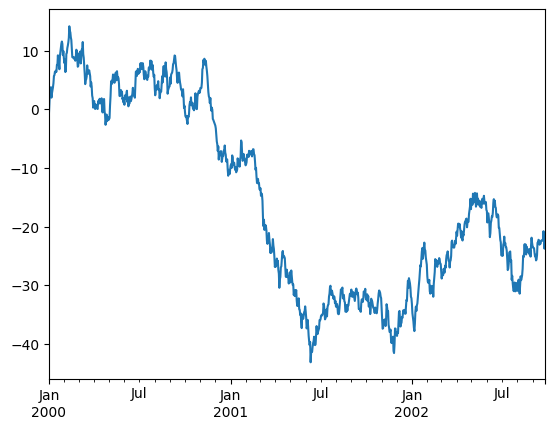

In [116]:
import matplotlib.pyplot as plt
plt.close("all")

ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))
ts = ts.cumsum()
print(ts)
ts.plot()

(1000, 4)


<Figure size 640x480 with 0 Axes>

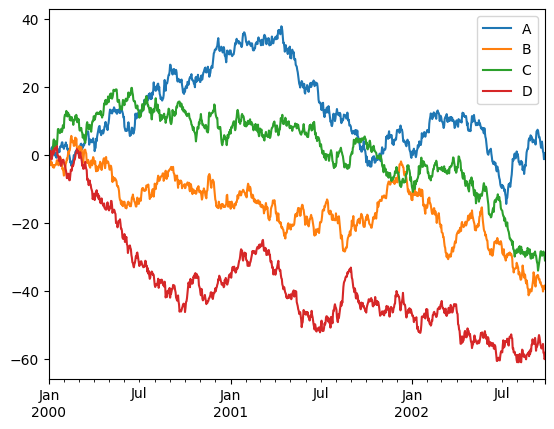

In [117]:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)
print(df.shape)
df = df.cumsum()

plt.figure()
df.plot()
plt.legend(loc='best')

# np.random.randn(1000, 4) 生成 1000 行 4 列的正态分布随机数

In [118]:
from pathlib import Path

df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))
print(df)

path = Path().cwd() / 'output'
print(path)

df.to_csv(path / "foo.csv") # 保存为 csv 文件
pd.read_csv(path / "foo.csv") # 打印 csv 文件内容

df.to_parquet(path / "foo.parquet") # Parquet 是一种列式存储的数据文件格式，常用于大数据和分析场景，格式为二进制
pd.read_parquet(path / "foo.parquet") # 打印 parquet 文件内容

df.to_excel(path / "foo.xlsx", sheet_name="Sheet1") 
pd.read_excel(path / "foo.xlsx", index_col=None, na_values=["NA"])
# pd.read_excel("foo.xlsx", index_col=None, na_values=["NA"])
# index_col	None	不把任何列作为索引
# na_values	["NA"]	将这些值作为缺失值

   0  1  2  3  4
0  2  4  1  2  3
1  1  3  2  4  1
2  0  1  2  0  1
3  2  3  0  0  0
4  0  1  3  3  1
5  3  0  1  1  0
6  0  4  2  4  3
7  1  3  0  4  3
8  2  4  3  2  4
9  3  4  2  1  2
c:\Users\hp\Desktop\Python_Projects\my_project\09_pyda-2e_study\output


,Unnamed: 0,0,1,2,3,4
0,0,2,4,1,2,3
1,1,1,3,2,4,1
2,2,0,1,2,0,1
3,3,2,3,0,0,0
4,4,0,1,3,3,1
5,5,3,0,1,1,0
6,6,0,4,2,4,3
7,7,1,3,0,4,3
8,8,2,4,3,2,4
9,9,3,4,2,1,2
